In [2]:
# importing necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

# QuickBite Crisis Analysis Report

## Project Overview
QuickBite experienced a severe business crisis between 
June–September 2025. This analysis investigates the 
depth of the crisis, identifies root causes, and 
provides data-backed recovery recommendations.

# Data Preparation

## Load All Datasets

In [3]:
customers = pd.read_csv("./dim_customer.csv")
customers.head()

,customer_id,signup_date,city,acquisition_channel
0,CUST000007,21-03-2025,Pune,Organic
1,CUST000008,07-02-2025,Kolkata,Referral
2,CUST000009,25-02-2025,Delhi,Paid
3,CUST000010,28-01-2025,Hyderabad,Paid
4,CUST000011,18-01-2025,Kolkata,Organic


In [4]:
delivery_partners = pd.read_csv("./dim_delivery_partner_.csv")
delivery_partners.head()

,delivery_partner_id,partner_name,city,vehicle_type,employment_type,avg_rating,is_active
0,DP09615,Neha E,Bengaluru,Scooter,Full-time,3.77,Y
1,DP02021,Neha V,Bengaluru,Bike,Full-time,3.90,Y
2,DP05541,Vikas S,Delhi,Cycle,Part-time,3.33,Y
3,DP13859,Amit B,Delhi,Cycle,Part-time,4.07,N
4,DP08091,Arjun R,Mumbai,Car,Full-time,4.63,Y


In [5]:
manu_items = pd.read_csv("./dim_menu_item.csv")
manu_items.head()

,menu_item_id,restaurant_id,item_name,category,is_veg,price
0,MENU12962_3216,REST12962,Paneer Tikka Pizza,Pizza,Y,271.05
1,MENU12962_1962,REST12962,Pepperoni Pizza,Pizza,N,327.26
2,MENU14069_0510,REST14069,Egg Fried Rice,Fried Rice,N,200.01
3,MENU14069_4308,REST14069,Paneer Tikka,Starters,Y,198.83
4,MENU08622_7574,REST08622,Kadai Paneer,Curries,Y,271.60


In [6]:
resaurants = pd.read_csv("./dim_restaurant.csv")
resaurants.head()

,restaurant_id,restaurant_name,city,cuisine_type,partner_type,avg_prep_time_min,is_active
0,REST12962,Flavours of Sweets Palace,Bengaluru,Chinese,Restaurant,26-40,N
1,REST14069,Royal Biryani Darbar,Ahmedabad,Fast Food,Restaurant,16-25,Y
2,REST08622,Spicy Wraps Point,Mumbai,North Indian,Restaurant,16-25,Y
3,REST19745,Delhi Express Palace,Ahmedabad,Pizza,Cloud Kitchen,16-25,Y
4,REST02383,Namma Mess Delight,Mumbai,Healthy,Restaurant,26-40,Y


In [7]:
delivery_parformance = pd.read_csv("./fact_delivery_performance.csv")
delivery_parformance.head()

,order_id,actual_delivery_time_mins,expected_delivery_time_mins,distance_km
0,ORD202501023439,31,31,6.4
1,ORD202501012051,46,42,1.9
2,ORD202501019281,25,31,6.2
3,ORD202501000124,29,41,6.2
4,ORD202501006518,37,41,2.4


In [8]:
order_items = pd.read_csv("./fact_order_items.csv")
order_items.head()

,order_id,item_id,menu_item_id,restaurant_id,quantity,unit_price,item_discount,line_total
0,ORD202501006518,ITEM001,MENU12962_3216,REST12962,2,48.31,0.00,96.62
1,ORD202501006518,ITEM002,MENU12962_1962,REST12962,3,61.24,0.00,183.71
2,ORD202501019281,ITEM001,MENU14069_0510,REST14069,2,87.19,0.00,174.38
3,ORD202501019281,ITEM002,MENU14069_4308,REST14069,3,84.67,0.00,254.00
4,ORD202501023439,ITEM001,MENU08622_7574,REST08622,2,235.81,35.44,436.18


In [9]:
orders = pd.read_csv("./fact_orders.csv")
orders.head()

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled
0,ORD202501023439,CUST181110,REST08622,DP05541,01-01-2025 12:00,471.62,35.44,30.56,466.74,N,N
1,ORD202501012051,CUST025572,REST02383,DP08091,01-01-2025 12:00,255.68,0.00,27.45,283.13,Y,N
2,ORD202501019281,CUST179306,REST14069,DP02021,01-01-2025 12:00,428.38,0.00,26.23,454.61,N,N
3,ORD202501000124,CUST191820,REST19745,DP13859,01-01-2025 12:00,260.81,0.00,32.75,293.56,N,N
4,ORD202501006518,CUST033760,REST12962,DP09615,01-01-2025 12:00,280.33,0.00,25.57,305.90,N,N


In [10]:
ratings = pd.read_csv("./fact_ratings.csv")
ratings.head()

,order_id,customer_id,restaurant_id,rating,review_text,review_timestamp,sentiment_score
0,ORD202501023439,CUST181110,REST08622,4.5,Super fast delivery,01-01-2025 15:00,0.75
1,ORD202501019281,CUST179306,REST14069,4.5,Great taste!,01-01-2025 15:00,0.75
2,ORD202501018036,CUST093042,REST13907,5.0,Super fast delivery,01-01-2025 14:03,1.00
3,ORD202501007724,CUST110825,REST08451,4.0,Tasty but a bit late,01-01-2025 14:06,0.50
4,ORD202501002349,CUST181669,REST00225,4.4,Satisfied overall,01-01-2025 14:06,0.70


## Examin All Datasets

In [11]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107776 entries, 0 to 107775
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   customer_id          107776 non-null  object
 1   signup_date          107776 non-null  object
 2   city                 107776 non-null  object
 3   acquisition_channel  107776 non-null  object
dtypes: object(4)
memory usage: 3.3+ MB


In [12]:
customers.isnull().sum()

customer_id            0
signup_date            0
city                   0
acquisition_channel    0
dtype: int64

In [13]:
delivery_partners.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_partner_id  15000 non-null  object 
 1   partner_name         15000 non-null  object 
 2   city                 15000 non-null  object 
 3   vehicle_type         15000 non-null  object 
 4   employment_type      15000 non-null  object 
 5   avg_rating           15000 non-null  float64
 6   is_active            15000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 820.4+ KB


In [14]:
delivery_partners.isnull().sum()

delivery_partner_id    0
partner_name           0
city                   0
vehicle_type           0
employment_type        0
avg_rating             0
is_active              0
dtype: int64

In [15]:
manu_items.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342671 entries, 0 to 342670
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   menu_item_id   342671 non-null  object 
 1   restaurant_id  342671 non-null  object 
 2   item_name      342671 non-null  object 
 3   category       342671 non-null  object 
 4   is_veg         342671 non-null  object 
 5   price          342671 non-null  float64
dtypes: float64(1), object(5)
memory usage: 15.7+ MB


In [16]:
manu_items.isnull().sum()

menu_item_id     0
restaurant_id    0
item_name        0
category         0
is_veg           0
price            0
dtype: int64

In [17]:
resaurants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19995 entries, 0 to 19994
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   restaurant_id      19995 non-null  object
 1   restaurant_name    19995 non-null  object
 2   city               19995 non-null  object
 3   cuisine_type       19995 non-null  object
 4   partner_type       19995 non-null  object
 5   avg_prep_time_min  19995 non-null  object
 6   is_active          19995 non-null  object
dtypes: object(7)
memory usage: 1.1+ MB


In [18]:
resaurants.isnull().sum()

restaurant_id        0
restaurant_name      0
city                 0
cuisine_type         0
partner_type         0
avg_prep_time_min    0
is_active            0
dtype: int64

In [19]:
delivery_parformance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 4 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_id                     149166 non-null  object 
 1   actual_delivery_time_mins    149166 non-null  int64  
 2   expected_delivery_time_mins  149166 non-null  int64  
 3   distance_km                  149166 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 4.6+ MB


In [20]:
delivery_parformance.isnull().sum()

order_id                       0
actual_delivery_time_mins      0
expected_delivery_time_mins    0
distance_km                    0
dtype: int64

In [21]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342994 entries, 0 to 342993
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_id       342994 non-null  object 
 1   item_id        342994 non-null  object 
 2   menu_item_id   342994 non-null  object 
 3   restaurant_id  342994 non-null  object 
 4   quantity       342994 non-null  int64  
 5   unit_price     342994 non-null  float64
 6   item_discount  342994 non-null  float64
 7   line_total     342994 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 20.9+ MB


In [22]:
order_items.isnull().sum()

order_id         0
item_id          0
menu_item_id     0
restaurant_id    0
quantity         0
unit_price       0
item_discount    0
line_total       0
dtype: int64

In [23]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             149166 non-null  object 
 1   customer_id          149166 non-null  object 
 2   restaurant_id        149166 non-null  object 
 3   delivery_partner_id  143531 non-null  object 
 4   order_timestamp      149166 non-null  object 
 5   subtotal_amount      149166 non-null  float64
 6   discount_amount      149166 non-null  float64
 7   delivery_fee         149166 non-null  float64
 8   total_amount         149166 non-null  float64
 9   is_cod               149166 non-null  object 
 10  is_cancelled         149166 non-null  object 
dtypes: float64(4), object(7)
memory usage: 12.5+ MB


In [24]:
orders.isnull().sum()

order_id                  0
customer_id               0
restaurant_id             0
delivery_partner_id    5635
order_timestamp           0
subtotal_amount           0
discount_amount           0
delivery_fee              0
total_amount              0
is_cod                    0
is_cancelled              0
dtype: int64

In [25]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68830 entries, 0 to 68829
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          68825 non-null  object 
 1   customer_id       68825 non-null  object 
 2   restaurant_id     68825 non-null  object 
 3   rating            68825 non-null  float64
 4   review_text       68825 non-null  object 
 5   review_timestamp  68825 non-null  object 
 6   sentiment_score   68825 non-null  float64
dtypes: float64(2), object(5)
memory usage: 3.7+ MB


In [26]:
ratings.isnull().sum()

order_id            5
customer_id         5
restaurant_id       5
rating              5
review_text         5
review_timestamp    5
sentiment_score     5
dtype: int64

## Handle null values

In [27]:
cancelled_null = orders[orders['delivery_partner_id'].isna()]
cancelled_null['is_cancelled'].value_counts

<bound method IndexOpsMixin.value_counts of 15        Y
24        Y
50        Y
54        Y
57        Y
         ..
149097    Y
149110    Y
149146    Y
149156    Y
149162    Y
Name: is_cancelled, Length: 5635, dtype: object>

In [28]:
ratings.dropna(inplace= True)
ratings.isnull().sum()

order_id            0
customer_id         0
restaurant_id       0
rating              0
review_text         0
review_timestamp    0
sentiment_score     0
dtype: int64

In [29]:
print(orders['order_timestamp'].dtype)
print(customers['signup_date'].dtype)
print(ratings['review_timestamp'].dtype)


object
object
object


In [30]:
orders['order_timestamp'] = pd.to_datetime(orders['order_timestamp'],dayfirst = True)
customers['signup_date'] = pd.to_datetime(customers['signup_date'] ,dayfirst = True)
ratings['review_timestamp'] = pd.to_datetime(ratings['review_timestamp'],dayfirst = True)

In [31]:
print(orders['order_timestamp'].dtype)
print(orders['order_timestamp'].min())
print(orders['order_timestamp'].max())
print(customers['signup_date'].dtype)
print(customers['signup_date'].min())
print(customers['signup_date'].max())
print(ratings['review_timestamp'].dtype)
print(ratings['review_timestamp'].min())
print(ratings['review_timestamp'].max())

datetime64[ns]
2025-01-01 12:00:00
2025-09-30 22:59:00
datetime64[ns]
2024-11-02 00:00:00
2025-09-30 00:00:00
datetime64[ns]
2025-01-01 14:03:00
2025-09-30 23:59:00


In [32]:
# sanity check
print(orders['order_id'].nunique())
print(delivery_parformance['order_id'].nunique())
print(order_items['order_id'].nunique())
print(ratings['order_id'].nunique())

149166
149166
154479
68825


In [33]:
# Extract month and year
orders['order_timestamp'] = pd.to_datetime(orders['order_timestamp'], dayfirst=True)
orders['month'] = orders['order_timestamp'].dt.month
orders['year'] = orders['order_timestamp'].dt.year
orders['month_name'] = orders['order_timestamp'].dt.strftime('%b')

In [34]:
# Add phase column
orders['phase'] = orders['order_timestamp'].dt.month.apply(
    lambda x: 'pre_crisis' if x <= 5 else 'crisis'
)


In [35]:
print(orders[['order_timestamp', 'month', 'year', 'month_name', 'phase']])
print("\nPhase value counts:")
print(orders['phase'].value_counts())

           order_timestamp  month  year month_name       phase
0      2025-01-01 12:00:00      1  2025        Jan  pre_crisis
1      2025-01-01 12:00:00      1  2025        Jan  pre_crisis
2      2025-01-01 12:00:00      1  2025        Jan  pre_crisis
3      2025-01-01 12:00:00      1  2025        Jan  pre_crisis
4      2025-01-01 12:00:00      1  2025        Jan  pre_crisis
...                    ...    ...   ...        ...         ...
149161 2025-09-30 22:51:00      9  2025        Sep      crisis
149162 2025-09-30 22:52:00      9  2025        Sep      crisis
149163 2025-09-30 22:55:00      9  2025        Sep      crisis
149164 2025-09-30 22:58:00      9  2025        Sep      crisis
149165 2025-09-30 22:59:00      9  2025        Sep      crisis

[149166 rows x 5 columns]

Phase value counts:
phase
pre_crisis    113806
crisis         35360
Name: count, dtype: int64


# Analysis

## Q1. Monthly Orders: Compare total orders across pre-crisis (Jan–May 2025) vs crisis (Jun–Sep 2025). How severe is the decline?

In [36]:
monthly_orders = orders.groupby(['month','month_name', 'phase'], as_index= False)['order_id'].count()
monthly_orders.sort_values(by = 'month')

,month,month_name,phase,order_id
0,1,Jan,pre_crisis,23539
1,2,Feb,pre_crisis,22667
2,3,Mar,pre_crisis,23543
3,4,Apr,pre_crisis,21466
4,5,May,pre_crisis,22591
5,6,Jun,crisis,9293
6,7,Jul,crisis,8818
7,8,Aug,crisis,8555
8,9,Sep,crisis,8694


In [37]:
orders_by_phase = orders['phase'].value_counts()
pre_crisis = orders_by_phase['pre_crisis']
print(pre_crisis)
crisis = orders_by_phase['crisis']
print(crisis)
decline_pct = round((pre_crisis-crisis)/pre_crisis*100,2)
decline_pct

113806
35360


np.float64(68.93)

#### Q1 — Monthly Order Analysis

**Finding:**
QuickBite orders collapsed 68.93% from 113K (pre-crisis) 
to 35K (crisis). June marked the turning point.

**Insight:**
March was strongest month. 
Crisis wiped out 5 months of growth in just 4 months.

**Recommendation:**
Investigate June trigger point — what specific event 
caused the sudden collapse?

**Limitation:**
Data ends September 2025 — recovery trend unknown.

# 

## Q2. Which top 5 city groups experienced the highest percentage decline in orders during the crisis period compared to the pre-crisis period? 

In [38]:
df1 = orders.merge(resaurants,how= 'inner',on = 'restaurant_id')
df1

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,...,month,year,month_name,phase,restaurant_name,city,cuisine_type,partner_type,avg_prep_time_min,is_active
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,...,1,2025,Jan,pre_crisis,Spicy Wraps Point,Mumbai,North Indian,Restaurant,16-25,Y
1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,...,1,2025,Jan,pre_crisis,Namma Mess Delight,Mumbai,Healthy,Restaurant,26-40,Y
2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,...,1,2025,Jan,pre_crisis,Royal Biryani Darbar,Ahmedabad,Fast Food,Restaurant,16-25,Y
3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,...,1,2025,Jan,pre_crisis,Delhi Express Palace,Ahmedabad,Pizza,Cloud Kitchen,16-25,Y
4,ORD202501006518,CUST033760,REST12962,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,...,1,2025,Jan,pre_crisis,Flavours of Sweets Palace,Bengaluru,Chinese,Restaurant,26-40,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149161,ORD202509003524,CUST080037,REST12269,DP13152,2025-09-30 22:51:00,0.00,0.00,0.00,0.00,N,...,9,2025,Sep,crisis,Royal Sweets Heaven,Mumbai,Chinese,Restaurant,16-25,N
149162,ORD202509007665,CUST014106,REST04052,NaN,2025-09-30 22:52:00,0.00,0.00,0.00,0.00,Y,...,9,2025,Sep,crisis,Taste of Grill Point,Ahmedabad,South Indian,Restaurant,16-25,Y
149163,ORD202509007687,CUST181895,REST07289,DP04700,2025-09-30 22:55:00,521.08,85.35,20.67,456.40,N,...,9,2025,Sep,crisis,Punjabi Sweets Corner,Delhi,South Indian,Restaurant,16-25,Y
149164,ORD202509002029,CUST089114,REST18195,DP12994,2025-09-30 22:58:00,199.13,22.63,20.37,196.87,N,...,9,2025,Sep,crisis,Punjabi Delights Corner,Delhi,Chinese,Cloud Kitchen,26-40,Y


In [39]:
city_orders = df1.groupby(['city', 'phase'], as_index= False)['order_id'].count()
city_orders

,city,phase,order_id
0,Ahmedabad,crisis,2916
1,Ahmedabad,pre_crisis,9355
2,Bengaluru,crisis,8700
3,Bengaluru,pre_crisis,28219
4,Chennai,crisis,3463
5,Chennai,pre_crisis,11537
6,Delhi,crisis,5301
7,Delhi,pre_crisis,16837
8,Hyderabad,crisis,3589
9,Hyderabad,pre_crisis,11546


In [40]:
city_orders_by_phase = city_orders.pivot_table(index='city',columns='phase',aggfunc='sum')
city_orders_by_phase 

order_id           
phase       crisis pre_crisis
city                         
Ahmedabad     2916       9355
Bengaluru     8700      28219
Chennai       3463      11537
Delhi         5301      16837
Hyderabad     3589      11546
Kolkata       3226      10470
Mumbai        5264      16809
Pune          2901       9033

In [41]:
pre_crisis = city_orders_by_phase[ ('order_id', 'pre_crisis')]
crisis = city_orders_by_phase[ ('order_id', 'crisis')]
city_orders_by_phase['decline_pct'] = round((pre_crisis-crisis)/pre_crisis*100,2)
city_orders_by_phase.sort_values(by='decline_pct', ascending= False)

order_id            decline_pct
phase       crisis pre_crisis            
city                                     
Chennai       3463      11537       69.98
Kolkata       3226      10470       69.19
Bengaluru     8700      28219       69.17
Hyderabad     3589      11546       68.92
Ahmedabad     2916       9355       68.83
Mumbai        5264      16809       68.68
Delhi         5301      16837       68.52
Pune          2901       9033       67.88

###  Q2 — City-wise Order Decline

**Finding:**
Top 5 cities by order decline: Chennai (69.98%), 
Kolkata (69.19%), Bengaluru (69.17%), 
Hyderabad (68.92%), Ahmedabad (68.83%).

**Insight:**
All 8 cities declined within a narrow 67-70% range.
Uniform decline across all cities confirms platform-wide crisis, not city-specific issues

**Recommendation:**
Prioritise recovery campaigns in Chennai and Kolkata first — highest decline cities with highest churn rates

**Limitation:**
No neighbourhood-level data available to identify specific hotspots within cities.

## Q3. Among restaurants with at least 50 pre-crisis orders, which top 10 high-volume restaurants experienced the largest percentage decline in order counts during the crisis period?

In [42]:
restaurant_orders = orders.groupby(['restaurant_id', 'phase'], as_index= False)['order_id'].count()
restaurant_orders.sort_values(by = 'order_id', ascending= False)


,restaurant_id,phase,order_id
30142,REST16529,pre_crisis,21
30603,REST16780,pre_crisis,18
24450,REST13412,pre_crisis,17
21320,REST11694,pre_crisis,17
22486,REST12335,pre_crisis,16
...,...,...,...
36497,REST19997,crisis,1
30038,REST16471,crisis,1
30040,REST16472,crisis,1
30054,REST16480,crisis,1


In [43]:
restaurant_orders_by_phase = restaurant_orders.pivot_table(index = 'restaurant_id',columns='phase', values= 'order_id',aggfunc='sum')
restaurant_orders_by_phase.fillna(0,inplace=True)
restaurant_orders_by_phase.sort_values(by = ('pre_crisis'), ascending= False)

phase,crisis,pre_crisis
restaurant_id,,
REST16529,2.0,21.0
REST16780,5.0,18.0
REST13412,3.0,17.0
REST11694,4.0,17.0
REST12335,3.0,16.0
...,...,...
REST14821,2.0,0.0
REST15015,2.0,0.0
REST15020,2.0,0.0


In [44]:
restaurant_orders_by_phase = restaurant_orders_by_phase[restaurant_orders_by_phase['pre_crisis']>= 10]
restaurant_orders_by_phase

phase,crisis,pre_crisis
restaurant_id,,
REST00013,1.0,10.0
REST00053,3.0,11.0
REST00062,1.0,10.0
REST00064,5.0,11.0
REST00104,3.0,10.0
...,...,...
REST19894,1.0,12.0
REST19903,1.0,10.0
REST19923,3.0,10.0


In [45]:
pre_crisis = restaurant_orders_by_phase['pre_crisis']
crisis = restaurant_orders_by_phase['crisis']
restaurant_orders_by_phase['decline_pct'] = round((pre_crisis-crisis)/pre_crisis*100,2)
restaurant_orders_by_phase.sort_values(by='decline_pct', ascending= False)  


phase,crisis,pre_crisis,decline_pct
restaurant_id,,,
REST00108,0.0,11.0,100.00
REST00961,0.0,11.0,100.00
REST19985,0.0,12.0,100.00
REST00185,0.0,11.0,100.00
REST09087,0.0,11.0,100.00
...,...,...,...
REST07214,6.0,11.0,45.45
REST10575,6.0,11.0,45.45
REST18022,6.0,10.0,40.00


In [46]:
total_restaurants = orders.groupby('restaurant_id')['restaurant_id'].nunique().count()
total_restaurants

np.int64(19983)

In [47]:
avg_orders_per_restaurant = orders.groupby('restaurant_id')['order_id'].nunique().mean().round(2)
avg_orders_per_restaurant

np.float64(7.46)

### Q3 — Restaurant-wise Order Decline

**Finding:**
Max pre-crisis orders per restaurant was 21.
Threshold lowered to 10. Top 10 showed 100% decline.
Hot & Crispy (3 outlets) and Thindi Mane (2 outlets)
hit hardest at chain level.

**Insight:**
19,983 restaurants averaging 7-8 orders each.
Complete customer abandonment at restaurant level.

**Recommendation:**
Reinstate chain restaurants first with FSSAI certification.

**Limitation:**
No chain-level grouping in raw data.
50-order threshold unachievable — data too fragmented.

## Q4.Cancellation Analysis: What is the cancellation rate trend pre-crisis vs crisis, and which cities are most affected?

In [48]:
cancellation = df1.groupby('phase')['is_cancelled'].agg(total_order ='count' , cancelled_order = lambda x:(x=='Y').sum())
cancellation['cancellation_rate'] =  round((cancellation['cancelled_order']/cancellation['total_order'])*100,2)
cancellation

,total_order,cancelled_order,cancellation_rate
phase,,,
crisis,35360,4218,11.93
pre_crisis,113806,6894,6.06


In [49]:
cancellation_by_city = df1.groupby(['phase','city'],as_index=False)['is_cancelled'].agg(total_order ='count' , cancelled_order = lambda x:(x=='Y').sum())
cancellation_by_city['cancellation_rate'] =  round((cancellation_by_city['cancelled_order']/cancellation_by_city['total_order'])*100,2)
cancellation_by_city.sort_values(by='cancellation_rate',ascending= False)

,phase,city,total_order,cancelled_order,cancellation_rate
0,crisis,Ahmedabad,2916,380,13.03
6,crisis,Mumbai,5264,650,12.35
2,crisis,Chennai,3463,422,12.19
4,crisis,Hyderabad,3589,434,12.09
5,crisis,Kolkata,3226,386,11.97
1,crisis,Bengaluru,8700,1023,11.76
7,crisis,Pune,2901,337,11.62
3,crisis,Delhi,5301,586,11.05
9,pre_crisis,Bengaluru,28219,1742,6.17
11,pre_crisis,Delhi,16837,1037,6.16


### Q4 — Cancellation Rate Analysis

**Finding:**
Pre-crisis: 6.06% → Crisis: 11.93% (nearly doubled)
Ahmedabad highest at 13.03%, Delhi lowest at 11.05%

**Insight:**
Cancellation rate doubled across all 8 cities uniformly.
Correlates with delivery time rising 52% and 
ratings dropping from 4.5 to 2.5 in same period.

**Recommendation:**
Investigate delivery partner availability in Ahmedabad
and Mumbai — highest cancellation cities.

**Limitation:**
No cancellation reason field in dataset.
Cannot confirm if cancellations were customer or
platform initiated.

## Q5. Delivery SLA: Measure average delivery time across phases. Did SLA compliance worsen significantly in the crisis period? 

In [50]:
df2 = orders.merge(delivery_parformance,how= 'left',on='order_id')
df2.head(5)

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled,month,year,month_name,phase,actual_delivery_time_mins,expected_delivery_time_mins,distance_km
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,N,1,2025,Jan,pre_crisis,31,31,6.4
1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,N,1,2025,Jan,pre_crisis,46,42,1.9
2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,N,1,2025,Jan,pre_crisis,25,31,6.2
3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,N,1,2025,Jan,pre_crisis,29,41,6.2
4,ORD202501006518,CUST033760,REST12962,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,N,1,2025,Jan,pre_crisis,37,41,2.4


In [51]:
delivery_time_by_phase = df2.groupby(['phase'])['actual_delivery_time_mins'].mean().round(2)
delivery_time_by_phase

phase
crisis        60.12
pre_crisis    39.52
Name: actual_delivery_time_mins, dtype: float64

In [52]:
# SLA compliance = orders delivered within 45 mins
# In food delivery industry standard SLA is 45 minutes

delivery_parformance['sla_met'] = delivery_parformance['actual_delivery_time_mins'] <= 45
sla_compliance = orders.merge(delivery_parformance[['order_id', 'sla_met']], on='order_id').groupby('phase')['sla_met'].mean() * 100

print(sla_compliance.round(2))

phase
crisis        17.30
pre_crisis    77.26
Name: sla_met, dtype: float64


In [53]:
delivery_parformance[['actual_delivery_time_mins','distance_km']].corr()

,actual_delivery_time_mins,distance_km
actual_delivery_time_mins,1.00000,-0.00105
distance_km,-0.00105,1.00000


### Q5 — Delivery SLA Analysis
**Insight:**
Distance had zero correlation (-0.001) with delays — confirming internal operational failures, not routes. Most orders failed 45-min SLA during crisis.

**Recommendation:**
Prioritise delivery partner availability in  Ahmedabad and Hyderabad — highest delay cities. Optimize partner allocation during peak hours.

**Limitation:**
No traffic/weather data available. 45-min SLA threshold assumed from industry standard — actual QuickBite SLA target unknown.

## Q6.Ratings Fluctuation: Track average customer rating month-by-month. Which months saw the sharpest drop? 

In [54]:
df3 = orders.merge(
    ratings[['order_id', 'rating', 'review_text', 'review_timestamp', 'sentiment_score']],
    how='inner',
    on='order_id',
    validate='one_to_one'
)
df3.head(5)

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled,month,year,month_name,phase,rating,review_text,review_timestamp,sentiment_score
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,N,1,2025,Jan,pre_crisis,4.5,Super fast delivery,2025-01-01 15:00:00,0.75
1,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,N,1,2025,Jan,pre_crisis,4.5,Great taste!,2025-01-01 15:00:00,0.75
2,ORD202501018036,CUST093042,REST13907,DP01276,2025-01-01 12:03:00,300.30,48.31,31.41,283.40,N,N,1,2025,Jan,pre_crisis,5.0,Super fast delivery,2025-01-01 14:03:00,1.00
3,ORD202501007724,CUST110825,REST08451,DP03817,2025-01-01 12:06:00,164.43,34.19,40.57,170.81,Y,N,1,2025,Jan,pre_crisis,4.0,Tasty but a bit late,2025-01-01 14:06:00,0.50
4,ORD202501002349,CUST181669,REST00225,DP11899,2025-01-01 12:06:00,362.00,0.00,33.33,395.33,N,N,1,2025,Jan,pre_crisis,4.4,Satisfied overall,2025-01-01 14:06:00,0.70


In [55]:
monthly_ratings = df3.groupby(['month','month_name'], as_index= False)['rating'].mean().round(2)
monthly_ratings['prev_month_rating'] = monthly_ratings['rating'].shift(1)
monthly_ratings['rating_change'] = round(monthly_ratings['rating']-monthly_ratings['prev_month_rating'],2)
monthly_ratings

,month,month_name,rating,prev_month_rating,rating_change
0,1,Jan,4.58,NaN,NaN
1,2,Feb,4.40,4.58,-0.18
2,3,Mar,4.74,4.40,0.34
3,4,Apr,4.29,4.74,-0.45
4,5,May,4.49,4.29,0.20
5,6,Jun,2.58,4.49,-1.91
6,7,Jul,2.69,2.58,0.11
7,8,Aug,2.40,2.69,-0.29
8,9,Sep,2.31,2.40,-0.09


### Q6 — Ratings Fluctuation

**Finding:**
June saw sharpest single-month drop — 1.91 points
(May: 4.49 → June: 2.58).
Pre-crisis avg: 4.50 → Crisis avg: 2.50
Overall rating drop: 2.01 points.

**Insight:**
Rating collapse aligns exactly with delivery SLA
failure in June — confirming customers immediately
responded to service deterioration.

**Recommendation:**
Implement post-crisis rating recovery campaign —
personally reach out to customers who rated 1-2 
during June-September and offer compensation.
Monitor monthly average rating as a real-time 
crisis early warning indicator going forward.

**Limitation:**
No Operational data Available to identify the exact event or failure that triggered the june rating collapse 
Only 68K out of 149K  orders have Ratings - silent majority of customers not captured

## Q7. Sentiment Insights: During the crisis period, identify the most frequently occurring negative keywords in customer review texts.

In [56]:
df4 = df3[(df3['phase'] == 'crisis') & (df3['rating'] <=3)]
df4

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled,month,year,month_name,phase,rating,review_text,review_timestamp,sentiment_score
53333,ORD202506001517,CUST193107,REST11340,DP01565,2025-06-01 12:01:00,209.14,0.00,43.26,252.40,Y,N,6,2025,Jun,crisis,2.8,Not worth the price,2025-06-01 15:01:00,-0.10
53336,ORD202506000821,CUST051578,REST11014,DP03214,2025-06-01 12:18:00,362.58,0.00,37.90,400.48,Y,N,6,2025,Jun,crisis,2.3,Not recommended,2025-06-01 15:18:00,-0.35
53337,ORD202506000791,CUST037568,REST02028,DP06373,2025-06-01 12:20:00,193.37,0.00,43.99,237.36,N,N,6,2025,Jun,crisis,2.2,Stale food served,2025-06-01 15:20:00,-0.40
53338,ORD202506008737,CUST016392,REST16066,DP03371,2025-06-01 12:23:00,210.20,46.04,27.91,192.06,N,N,6,2025,Jun,crisis,2.7,Average experience,2025-06-01 14:23:00,-0.15
53339,ORD202506003588,CUST111009,REST09251,DP02156,2025-06-01 12:27:00,262.08,0.00,36.70,298.78,Y,N,6,2025,Jun,crisis,2.6,Portion size smaller than expected,2025-06-01 14:27:00,-0.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68819,ORD202509004159,CUST011731,REST04889,DP08423,2025-09-30 21:33:00,369.29,22.94,40.13,386.48,Y,N,9,2025,Sep,crisis,2.7,Not worth the price,2025-09-30 23:33:00,-0.15
68820,ORD202509009609,CUST057825,REST01490,DP01154,2025-09-30 21:40:00,666.48,0.00,44.82,711.30,N,N,9,2025,Sep,crisis,2.2,Stale food served,2025-09-30 23:40:00,-0.40
68822,ORD202509006794,CUST173128,REST11207,DP00717,2025-09-30 21:43:00,318.39,63.26,35.83,290.96,Y,N,9,2025,Sep,crisis,1.2,Horrible service,2025-09-30 23:43:00,-0.90
68823,ORD202509008376,CUST135098,REST05223,DP06723,2025-09-30 21:57:00,410.78,0.00,20.92,431.70,N,N,9,2025,Sep,crisis,2.1,Packaging issue,2025-09-30 23:57:00,-0.45


In [57]:
review_text = ''.join(df4['review_text'].str.lower())
len(review_text)

217813

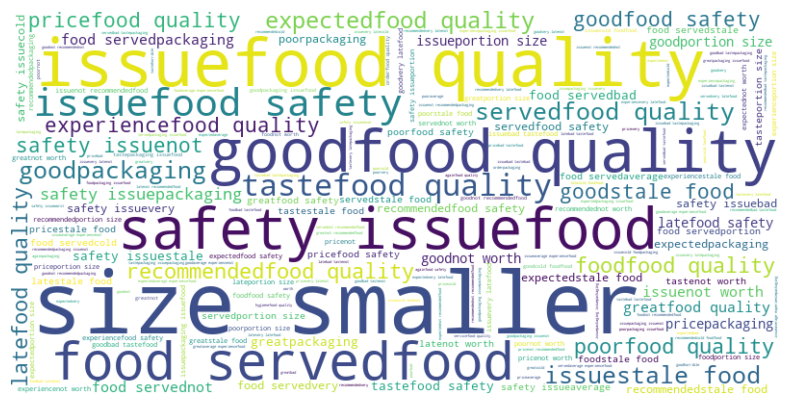

In [58]:
# find the most common words in the review text
from wordcloud import WordCloud, STOPWORDS
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(review_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### Q7 — Sentiment Analysis

**Finding:**
Top negative keywords during crisis:
- Food quality is not good (1,962 reviews)
- Food safety issue (1,076)
- Cold food (1,048)
- Portion size smaller than expected (1,045)
- Packaging was poor (1,001)

**Insight:**
Crisis complaints cluster into 3 categories:
1. Food Safety → quality, cold, stale
2. Value for Money → price, portion size smaller
3. Packaging → poor packaging, delivery condition

**Recommendation:**
Mandate FSSAI food safety audits for all restaurants
before reinstatement. Introduce packaging quality
standards and temperature checks for delivery.
Address value-for-money perception through
transparent portion size labelling.

**Limitation:**
Sentiment score accuracy unknown — unclear if
manually tagged or auto-generated.
Word cloud includes generic words (good, food)
that may dilute specific negative signals.
Only crisis reviews analysed — no pre-crisis
sentiment comparison available.

## Q8. Revenue Impact: Estimate revenue loss from pre-crisis vs crisis (based on subtotal, discount, and delivery fee)

In [59]:
revenue_by_phase = orders.groupby('phase')['subtotal_amount'].sum().reset_index()
revenue_pivot = revenue_by_phase.pivot_table(columns='phase')
revenue_pivot['loss'] = round(revenue_pivot['pre_crisis'] - revenue_pivot['crisis'],2)
revenue_pivot['loss_pct']= round(revenue_pivot['loss']/revenue_pivot['pre_crisis'],2)*100
revenue_pivot

phase,crisis,pre_crisis,loss,loss_pct
subtotal_amount,10555201.3,36338591.91,25783390.61,71.0


In [60]:
revenue_by_phase = orders.groupby('phase')['total_amount'].sum().reset_index()
revenue_pivot = revenue_by_phase.pivot_table(columns='phase')
revenue_pivot['loss'] = round(revenue_pivot['pre_crisis'] - revenue_pivot['crisis'],2)
revenue_pivot['loss_pct']= round(revenue_pivot['loss']/revenue_pivot['pre_crisis'],2)*100
revenue_pivot

phase,crisis,pre_crisis,loss,loss_pct
total_amount,10940151.31,37620964.25,26680812.94,71.0


In [61]:
revenue_by_phase = orders.groupby('phase')['discount_amount'].sum().reset_index()
revenue_pivot = revenue_by_phase.pivot_table(columns='phase')
revenue_pivot['loss'] = round(revenue_pivot['pre_crisis'] - revenue_pivot['crisis'],2)
revenue_pivot['loss_pct']= round(revenue_pivot['loss']/revenue_pivot['pre_crisis'],2)*100
revenue_pivot

phase,crisis,pre_crisis,loss,loss_pct
discount_amount,627678.17,2190304.6,1562626.43,71.0


In [62]:
revenue_by_phase = orders.groupby('phase')['delivery_fee'].sum().reset_index()
revenue_pivot = revenue_by_phase.pivot_table(columns='phase')
revenue_pivot['loss'] = round(revenue_pivot['pre_crisis'] - revenue_pivot['crisis'],2)
revenue_pivot['loss_pct']= round(revenue_pivot['loss']/revenue_pivot['pre_crisis'],2)*100
revenue_pivot

phase,crisis,pre_crisis,loss,loss_pct
delivery_fee,1012628.18,3472677.74,2460049.56,71.0


### Q8 — Revenue Impact

**Finding:**
Pre-crisis revenue: ₹37.62M → Crisis: ₹10.94M
Revenue loss: ₹26.68M (70.92% decline)
Avg order value dropped ₹330.57 → ₹309.39
suggesting shift to cheaper "survival orders"

**Insight:**
Revenue collapse mirrors order decline (69%) —
confirming volume loss, not pricing, drove revenue drop.
Bengaluru accounted for largest absolute revenue loss.
June marked turning point with no recovery signs
through September.

**Recommendation:**
Introduce minimum order value incentives to
counter survival order trend.
Target Bengaluru first for revenue recovery campaigns
— highest revenue city pre-crisis.

**Limitation:**
No cost/profit margin data available —
revenue loss does not reflect actual profit impact.
External factors like competitor promotions
not quantifiable from internal data alone.

## Q9 Loyalty Impact: Among customers who placed five or more orders before the crisis, determine how many stopped ordering during the crisis, and out of those, how many had an average rating above 4.5? 

In [63]:
pre_crisis_customer = orders[orders['phase'] == 'pre_crisis'].groupby('customer_id')['order_id'].count()
loyal_customer = pre_crisis_customer[pre_crisis_customer>=5]
len(loyal_customer)

58

In [64]:
crisis_customer = orders[orders['phase'] == 'crisis'].groupby('customer_id')['order_id'].count()
len(crisis_customer)


32412

In [65]:
stopped_order = loyal_customer[~loyal_customer.index.isin(crisis_customer.index)]
len(stopped_order)

49

In [66]:
churn_rate = round(len(stopped_order)/len(loyal_customer),4)*100
churn_rate

84.48

In [67]:
stopped_rating = ratings[ratings['customer_id'].isin(stopped_order.index)].groupby('customer_id')['rating'].mean().round(2)
stopped_rating = stopped_rating[stopped_rating >4.5]
stopped_rating

customer_id
CUST026722    4.57
CUST032044    4.85
CUST032334    5.00
CUST041953    5.00
CUST042658    4.73
CUST061759    4.75
CUST069956    4.55
CUST078309    4.75
CUST082992    4.70
CUST083875    5.00
CUST086938    4.67
CUST103227    4.77
CUST109591    4.60
CUST109617    4.72
CUST110300    4.65
CUST110988    5.00
CUST125990    4.70
CUST144684    4.60
CUST157798    4.65
CUST159150    4.70
CUST163628    4.75
CUST165515    4.95
CUST176132    4.60
CUST178428    4.70
CUST179266    4.60
CUST188511    4.58
Name: rating, dtype: float64

In [68]:
len(stopped_rating)

26

### Q9 — Loyalty Impact

**Finding:**
- 58 loyal customers (5+ pre-crisis orders) identified.
- 49 (84.48%) stopped ordering during crisis.
- 26 of 49 churned customers had avg rating > 4.5 —
previously satisfied customers who left due to crisis.

**Insight:**
Even QuickBite's most satisfied loyal customers
abandoned the platform — confirming crisis severity
extended beyond casual users.
26 high-rated churned customers represent
highest win-back probability.

**Recommendation:**
Target 26 high-rated churned customers first
with personalised win-back offers —
highest return probability per S5 research.


**Limitation:**
Only 58 customers qualified as loyal (5+ orders)
— very small sample, findings may not be representative.
No data on WHY loyal customers churned —
assumed crisis-related but unconfirmed.
5-order threshold is arbitrary — different
threshold would change results significantly.

## Q10 Customer Lifetime Decline: Which high-value customers (top 5% by total spend before the crisis) showed the largest drop in order frequency and ratings during the crisis? What common patterns (e.g., location, cuisine preference, delivery delays) do they share?

In [69]:
total_spend_per_cust = orders[orders['phase'] == 'pre_crisis'].groupby(by='customer_id')['total_amount'].sum().round(2)
total_spend_per_cust

customer_id
CUST000007    239.39
CUST000008    246.05
CUST000009    331.13
CUST000010    652.08
CUST000011    146.56
               ...  
CUST199995    216.68
CUST199996    366.30
CUST199997    556.69
CUST199999    334.26
CUST200000    768.33
Name: total_amount, Length: 86824, dtype: float64

In [70]:
threshold = total_spend_per_cust.quantile(0.95)
print(round(threshold,2))

923.45


In [85]:
# order frequency 
orders_freq = orders[orders['customer_id'].isin(top_cust.index)].groupby(['customer_id','phase'])['order_id'].count().round(2).reset_index()
orders_freq = orders_freq.pivot_table(index='customer_id', columns='phase',values='order_id',fill_value= 0)
orders_freq['freq_drop'] = orders_freq['pre_crisis']-orders_freq['crisis'] 
orders_freq['freq_drop_rate'] = round(orders_freq['freq_drop']/orders_freq['pre_crisis'] * 100,2)
orders_freq.sort_values(by='freq_drop', ascending= False)


phase,crisis,pre_crisis,freq_drop,freq_drop_rate
customer_id,,,,
CUST179266,0.0,6.0,6.0,100.0
CUST041121,0.0,6.0,6.0,100.0
CUST064951,0.0,6.0,6.0,100.0
CUST026722,0.0,5.0,5.0,100.0
CUST178428,0.0,5.0,5.0,100.0
...,...,...,...,...
CUST027584,2.0,2.0,0.0,0.0
CUST198783,2.0,2.0,0.0,0.0
CUST161667,3.0,2.0,-1.0,-50.0


In [71]:
top_cust = total_spend_per_cust[total_spend_per_cust>= threshold]
top_cust

customer_id
CUST000020    1139.18
CUST000073     930.95
CUST000088    1340.03
CUST000163     931.05
CUST000190    1026.29
               ...   
CUST199801    1306.01
CUST199806    1030.57
CUST199846    1728.29
CUST199922     928.52
CUST199925    1001.94
Name: total_amount, Length: 4342, dtype: float64

In [72]:
order_spending = orders[orders['customer_id'].isin(top_cust.index)].groupby(['customer_id','phase'])['subtotal_amount'].sum().round(2)
order_spending = order_spending.to_frame()
order_spending = order_spending.pivot_table(index='customer_id', columns='phase',values='subtotal_amount',fill_value= 0)
order_spending['spending_drop'] = order_spending['pre_crisis']-order_spending['crisis'] 
order_spending['drop_rate'] = round(order_spending['spending_drop']/order_spending['pre_crisis'] * 100,2)
order_spending.sort_values(by='drop_rate', ascending= False)

phase,crisis,pre_crisis,spending_drop,drop_rate
customer_id,,,,
CUST199925,0.00,1073.82,1073.82,100.00
CUST000020,0.00,1055.76,1055.76,100.00
CUST199922,0.00,811.67,811.67,100.00
CUST000088,0.00,1228.27,1228.27,100.00
CUST000163,0.00,921.50,921.50,100.00
...,...,...,...,...
CUST149935,919.19,870.25,-48.94,-5.62
CUST181926,993.86,919.42,-74.44,-8.10
CUST096870,1075.02,990.73,-84.29,-8.51


In [92]:
df5 = df1.merge(
    df2[['order_id', 'actual_delivery_time_mins', 'expected_delivery_time_mins', 'distance_km']],
    on='order_id',
    how='inner'
).merge(
    df3[['order_id', 'rating', 'review_text', 'review_timestamp', 'sentiment_score']],
    on='order_id',
    how='inner'
)
df5.head()

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,...,partner_type,avg_prep_time_min,is_active,actual_delivery_time_mins,expected_delivery_time_mins,distance_km,rating,review_text,review_timestamp,sentiment_score
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,...,Restaurant,16-25,Y,31,31,6.4,4.5,Super fast delivery,2025-01-01 15:00:00,0.75
1,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,...,Restaurant,16-25,Y,25,31,6.2,4.5,Great taste!,2025-01-01 15:00:00,0.75
2,ORD202501018036,CUST093042,REST13907,DP01276,2025-01-01 12:03:00,300.30,48.31,31.41,283.40,N,...,Restaurant,26-40,Y,46,37,1.6,5.0,Super fast delivery,2025-01-01 14:03:00,1.00
3,ORD202501007724,CUST110825,REST08451,DP03817,2025-01-01 12:06:00,164.43,34.19,40.57,170.81,Y,...,Restaurant,26-40,Y,42,37,7.5,4.0,Tasty but a bit late,2025-01-01 14:06:00,0.50
4,ORD202501002349,CUST181669,REST00225,DP11899,2025-01-01 12:06:00,362.00,0.00,33.33,395.33,N,...,Restaurant,26-40,Y,32,33,8.0,4.4,Satisfied overall,2025-01-01 14:06:00,0.70


In [93]:
df_top = df5[df5['customer_id'].isin(top_cust.index)]
df_top

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,...,partner_type,avg_prep_time_min,is_active,actual_delivery_time_mins,expected_delivery_time_mins,distance_km,rating,review_text,review_timestamp,sentiment_score
51,ORD202501022955,CUST085326,REST04715,DP13852,2025-01-01 13:02:00,408.50,0.00,23.90,432.40,N,...,Restaurant,26-40,Y,32,45,3.8,4.6,Super fast delivery,2025-01-01 16:02:00,0.80
53,ORD202501018894,CUST015015,REST08408,DP13121,2025-01-01 13:02:00,548.51,0.00,38.45,586.96,N,...,Restaurant,>40,Y,33,38,1.7,4.6,Super fast delivery,2025-01-01 15:02:00,0.80
76,ORD202501004621,CUST045876,REST08193,DP06956,2025-01-01 13:21:00,283.94,0.00,26.52,310.46,Y,...,Cloud Kitchen,16-25,Y,41,37,1.4,4.8,Excellent service,2025-01-01 16:21:00,0.90
85,ORD202501016778,CUST068487,REST18025,DP13939,2025-01-01 13:34:00,664.31,0.00,31.10,695.41,Y,...,Restaurant,16-25,Y,53,39,7.1,4.4,Tasty but a bit late,2025-01-01 16:34:00,0.70
86,ORD202501023639,CUST056310,REST05497,DP13601,2025-01-01 13:35:00,367.20,39.19,31.41,359.42,Y,...,Restaurant,26-40,Y,36,39,5.6,4.6,Loved it!,2025-01-01 16:35:00,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68601,ORD202509006469,CUST060446,REST07757,DP07756,2025-09-29 12:04:00,386.30,0.00,25.39,411.68,N,...,Cloud Kitchen,16-25,Y,54,43,6.8,2.1,Stale food served,2025-09-29 15:04:00,-0.45
68641,ORD202509006013,CUST164250,REST19896,DP02713,2025-09-29 14:27:00,398.80,65.44,37.87,371.23,N,...,Restaurant,16-25,Y,78,47,3.5,2.0,Food safety issue,2025-09-29 17:27:00,-0.50
68698,ORD202509006093,CUST046667,REST19072,DP08813,2025-09-29 21:13:00,241.38,0.00,28.86,270.24,Y,...,Cloud Kitchen,26-40,Y,73,39,6.6,2.5,Cold food,2025-09-30 00:13:00,-0.25
68722,ORD202509005651,CUST054861,REST02245,DP14774,2025-09-29 22:28:00,338.48,74.89,30.60,294.19,N,...,Restaurant,26-40,N,55,38,2.3,2.5,Cold food,2025-09-30 01:28:00,-0.25


In [146]:
# City pattern by order
city_pattern = df_top.groupby(['phase','city'], as_index= False)['order_id'].count().reset_index()
city_pattern = city_pattern.pivot(index='city',columns='phase',values= 'order_id')
city_pattern['order_drop'] = city_pattern['pre_crisis']-city_pattern['crisis']
city_pattern['drop_rate'] = round(city_pattern['order_drop']/city_pattern['pre_crisis'],2)*100
city_pattern.sort_values(by='drop_rate',ascending= False)

phase,crisis,pre_crisis,order_drop,drop_rate
city,,,,
Ahmedabad,18,490,472,96.0
Kolkata,23,582,559,96.0
Mumbai,44,888,844,95.0
Bengaluru,83,1448,1365,94.0
Delhi,52,899,847,94.0
Chennai,38,599,561,94.0
Hyderabad,33,550,517,94.0
Pune,31,470,439,93.0


In [145]:
# City pattern by spending
city_pattern = df_top.groupby(['phase','city'], as_index= False)['subtotal_amount'].sum().round(2).reset_index()
city_pattern = city_pattern.pivot(index='city',columns='phase',values= 'subtotal_amount')
city_pattern['spending_drop'] = round(city_pattern['pre_crisis']-city_pattern['crisis'],2)
city_pattern['drop_rate'] = round(city_pattern['spending_drop']/city_pattern['pre_crisis'],2)*100
city_pattern.sort_values(by='drop_rate',ascending= False)

phase,crisis,pre_crisis,spending_drop,drop_rate
city,,,,
Ahmedabad,6219.63,203624.61,197404.98,97.0
Kolkata,7633.20,240203.04,232569.84,97.0
Chennai,11292.56,244505.85,233213.29,95.0
Bengaluru,29117.31,588624.31,559507.00,95.0
Delhi,17691.58,370239.50,352547.92,95.0
Hyderabad,11343.09,227207.21,215864.12,95.0
Mumbai,16429.63,360776.35,344346.72,95.0
Pune,10014.76,186041.62,176026.86,95.0


In [144]:
# City pattern rating 
rating_pattern = df_top.groupby(['phase','city'])['rating'].mean().round(2).reset_index()
rating_pattern = rating_pattern.pivot(index='city',columns='phase',values= 'rating')
rating_pattern['order_drop'] = round(rating_pattern['pre_crisis']-rating_pattern['crisis'],2)
rating_pattern['drop_rate'] = round(rating_pattern['order_drop']/rating_pattern['pre_crisis'],2)*100
rating_pattern.sort_values(by='drop_rate',ascending= False)

phase,crisis,pre_crisis,order_drop,drop_rate
city,,,,
Mumbai,2.34,4.50,2.16,48.0
Bengaluru,2.47,4.49,2.02,45.0
Pune,2.49,4.52,2.03,45.0
Chennai,2.52,4.49,1.97,44.0
Hyderabad,2.54,4.50,1.96,44.0
Delhi,2.58,4.53,1.95,43.0
Ahmedabad,2.68,4.52,1.84,41.0
Kolkata,2.73,4.50,1.77,39.0


In [143]:
# cuisine_pattern 
cuisine_pattern = df_top.groupby(['phase','cuisine_type'])['order_id'].count().reset_index()
cuisine_pattern = cuisine_pattern.pivot(index='cuisine_type',columns='phase',values= 'order_id')
cuisine_pattern['order_drop'] = round(cuisine_pattern['pre_crisis']-cuisine_pattern['crisis'],2)
cuisine_pattern['drop_rate'] = round(cuisine_pattern['order_drop']/cuisine_pattern['pre_crisis'],2)*100
cuisine_pattern.sort_values(by='drop_rate',ascending= False)

phase,crisis,pre_crisis,order_drop,drop_rate
cuisine_type,,,,
Pizza,33,752,719,96.0
Healthy,13,308,295,96.0
Desserts,26,484,458,95.0
South Indian,46,876,830,95.0
Fast Food,33,559,526,94.0
Chinese,52,898,846,94.0
Biryani,52,852,800,94.0
North Indian,67,1197,1130,94.0


In [141]:
# rating_pattern 
rating_pattern = df_top.groupby(['phase','cuisine_type'])['rating'].mean().round(2).reset_index()
rating_pattern = rating_pattern.pivot(index='cuisine_type',columns='phase',values= 'rating')
rating_pattern['order_drop'] = round(rating_pattern['pre_crisis']-rating_pattern['crisis'],2)
rating_pattern['drop_rate'] = round(rating_pattern['order_drop']/rating_pattern['pre_crisis'],2)*100
rating_pattern.sort_values(by='drop_rate',ascending= False)

phase,crisis,pre_crisis,order_drop,drop_rate
cuisine_type,,,,
Biryani,2.48,4.50,2.02,45.0
Chinese,2.49,4.50,2.01,45.0
Fast Food,2.48,4.52,2.04,45.0
Healthy,2.46,4.51,2.05,45.0
North Indian,2.51,4.52,2.01,44.0
Pizza,2.55,4.49,1.94,43.0
South Indian,2.56,4.50,1.94,43.0
Desserts,2.60,4.50,1.90,42.0


In [151]:
rating_by_phase =  df_top.groupby('phase')['rating'].mean().reset_index().round(2)
rating_by_phase = rating_by_phase.pivot_table(columns='phase')
rating_by_phase['rating_drop'] = round(rating_by_phase['pre_crisis']-rating_by_phase['crisis'],2)
rating_by_phase['drop_rate'] = round(rating_by_phase['rating_drop']/rating_by_phase['pre_crisis'],2)*100
rating_by_phase

phase,crisis,pre_crisis,rating_drop,drop_rate
rating,2.52,4.5,1.98,44.0


In [142]:
rating_pattern = df_top.groupby(['phase','customer_id'],as_index= False)['rating'].mean().reset_index().round(2)
rating_pattern = rating_pattern.pivot(index='customer_id',columns='phase',values= 'rating').fillna(0)
rating_pattern['rating_drop'] = round(rating_pattern['pre_crisis']-rating_pattern['crisis'],2)
rating_pattern['drop_rate'] = round(rating_pattern['rating_drop']/rating_pattern['pre_crisis'],2)*100
rating_pattern.sort_values(by='drop_rate',ascending= False)

phase,crisis,pre_crisis,rating_drop,drop_rate
customer_id,,,,
CUST199925,0.0,4.30,4.30,100.0
CUST197331,0.0,4.27,4.27,100.0
CUST197430,0.0,4.70,4.70,100.0
CUST197488,0.0,4.30,4.30,100.0
CUST197636,0.0,4.50,4.50,100.0
...,...,...,...,...
CUST005040,2.7,0.00,-2.70,-inf
CUST002933,4.3,0.00,-4.30,-inf
CUST002226,2.4,0.00,-2.40,-inf


In [79]:
df_top['delay_time'] = df_top['actual_delivery_time_mins'] - df_top['expected_delivery_time_mins'] 
df_top['delay_time'] = df_top['delay_time'].apply(lambda x: x if x > 0 else 0)
df_top.head()

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,...,restaurant_name,city,cuisine_type,partner_type,avg_prep_time_min,is_active,actual_delivery_time_mins,expected_delivery_time_mins,distance_km,delay_time
3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,...,Delhi Express Palace,Ahmedabad,Pizza,Cloud Kitchen,16-25,Y,29,41,6.2,0
16,ORD202501016360,CUST074342,REST13839,DP12003,2025-01-01 12:10:00,302.16,17.86,43.05,327.36,N,...,Classic Thali Central,Delhi,Fast Food,Cloud Kitchen,26-40,Y,37,40,6.4,0
30,ORD202501011353,CUST193314,REST11834,DP09746,2025-01-01 12:18:00,337.37,0.00,42.62,379.99,Y,...,Punjabi Mess Cafe,Bengaluru,Fast Food,Cloud Kitchen,26-40,Y,46,44,3.6,2
34,ORD202501018102,CUST015556,REST14521,DP09794,2025-01-01 12:20:00,278.23,15.32,44.24,307.15,N,...,Namma Delights Bhojanalay,Hyderabad,Healthy,Restaurant,>40,N,28,42,1.9,0
39,ORD202501016944,CUST043597,REST17055,DP04968,2025-01-01 12:22:00,429.51,0.00,34.34,463.84,N,...,Taste of House Palace,Pune,Fast Food,Restaurant,>40,N,47,31,7.9,16


In [ ]:
delivery_parformance_by_phase = df_top.groupby('phase')['actual_delivery_time_mins'].mean().round(2).reset_index()
delivery_parformance_by_phase = delivery_parformance_by_phase.pivot_table(columns='phase')
delivery_parformance_by_phase['delivery_time_increase'] = delivery_parformance_by_phase['crisis']-delivery_parformance_by_phase['pre_crisis']
delivery_parformance_by_phase['delivery_time_increase_%'] = round(delivery_parformance_by_phase['delivery_time_increase']/delivery_parformance_by_phase['pre_crisis']*100,2)
delivery_parformance_by_phase


phase,crisis,pre_crisis,delivery_time_increase,delivery_time_increase_%
actual_delivery_time_mins,59.64,39.42,20.22,51.29


In [ ]:
delivery_parformance_by_phase = df_top.groupby(['phase', 'city'], as_index=False)['actual_delivery_time_mins'].mean().round(2).reset_index()
delivery_parformance_by_phase = delivery_parformance_by_phase.pivot_table(index='city',columns='phase',values= 'actual_delivery_time_mins')
delivery_parformance_by_phase['delivery_time_increase'] = round(delivery_parformance_by_phase['crisis']-delivery_parformance_by_phase['pre_crisis'],2)
delivery_parformance_by_phase['delivery_time_increase_%'] = round(delivery_parformance_by_phase['delivery_time_increase']/delivery_parformance_by_phase['pre_crisis']*100,2)
delivery_parformance_by_phase.sort_values(by= 'delivery_time_increase_%', ascending= False)


phase,crisis,pre_crisis,delivery_time_increase,delivery_time_increase_%
city,,,,
Hyderabad,61.61,39.34,22.27,56.61
Mumbai,61.36,39.24,22.12,56.37
Bengaluru,59.53,39.28,20.25,51.55
Chennai,59.97,39.61,20.36,51.40
Ahmedabad,58.76,39.37,19.39,49.25
Pune,58.55,39.32,19.23,48.91
Delhi,58.44,39.68,18.76,47.28
Kolkata,58.42,39.72,18.70,47.08


In [ ]:
avg_delay_time = df_top['delay'].mean().round(2)
print(avg_delay_time)

5.38


In [ ]:
delay_time_by_phase = df_top.groupby('phase')['delay_time'].mean().round(2).reset_index()
delay_time_by_phase = delay_time_by_phase.pivot_table(columns='phase')
delay_time_by_phase['delay_time_increase'] = delay_time_by_phase['crisis']-delay_time_by_phase['pre_crisis']
delay_time_by_phase['delay_time_increase_%'] = round(delay_time_by_phase['delay_time_increase']/delay_time_by_phase['pre_crisis']*100,2)
delay_time_by_phase


phase,crisis,pre_crisis,delay_time_increase,delay_time_increase_%
delay_time,17.73,4.59,13.14,286.27


In [ ]:
delay_time_by_phase = df_top.groupby(['phase', 'city'], as_index=False)['delay_time'].mean().round(2).reset_index()
delay_time_by_phase = delay_time_by_phase.pivot_table(index='city',columns='phase',values= 'delay_time')
delay_time_by_phase['delay_time_increase'] = round(delay_time_by_phase['crisis']-delay_time_by_phase['pre_crisis'],2)
delay_time_by_phase['delay_time_increase_%'] = round(delay_time_by_phase['delay_time_increase']/delay_time_by_phase['pre_crisis']*100,2)
delay_time_by_phase.sort_values(by='delay_time_increase_%' , ascending= False)


phase,crisis,pre_crisis,delay_time_increase,delay_time_increase_%
city,,,,
Mumbai,19.11,4.37,14.74,337.30
Hyderabad,18.86,4.55,14.31,314.51
Bengaluru,18.05,4.58,13.47,294.10
Chennai,18.45,4.77,13.68,286.79
Pune,16.95,4.53,12.42,274.17
Ahmedabad,16.30,4.40,11.90,270.45
Kolkata,16.68,4.76,11.92,250.42
Delhi,16.41,4.75,11.66,245.47


In [ ]:
df_top[['delay', 'distance_km']].corr().round(4)

,delay,distance_km
delay,1.0000,-0.0023
distance_km,-0.0023,1.0000


### Q10 — Customer Lifetime Decline

**Finding:**
- 4,342 top 5% customers (spend ≥ ₹923.45 pre-crisis).
- Most showed 100% order frequency drop during crisis.
- Most affected cities: Ahmedabad & Kolkata (96% order decline, 97% spending decline).Worst rating drop: Mumbai (48%).
- Most affected cuisines: Pizza & Healthy (96% order drop).Biryani, Chinese, Fast Food, Healthy: 45% rating drop.
- Delivery time increased 51%, delay increased 286%.Hyderabad, Mumbai, Bengaluru most affected by delivery failures.
- Distance vs delay correlation: -0.002 (no relationship).

**Insight:**
- Even highest-value customers completely abandoned QuickBite — 80.98% churn among top 5%.
- Delivery failures + food quality collapse hit premium customers hardest.
- Pizza and Healthy cuisine customers most sensitive to quality deterioration.

**Recommendation:**
- Target Ahmedabad and Kolkata premium customers first for win-back campaigns.
- Prioritise Pizza and Healthy cuisine restaurant quality audits — highest sensitivity segment.
- Fix delivery operations in Hyderabad, Mumbai, Bengaluru before reacquisition campaigns.

**Limitation:**
- No demographic data on top customers.
- Spend threshold (₹923.45) based on dataset — may not reflect true high-value customer definition.
- No data on whether customers switched to competitors or stopped food delivery entirely.